# 04. Model Fuzzy Tsukamoto

Setelah menyelesaikan notebook ini, mahasiswa diharapkan mampu menjelaskan cara kerja Tsukamoto, yaitu mencari nilai tiap aturan dari kurva output monoton lalu merata-ratakannya dengan bobot, dan menghitung keluaran sistem fuzzy Tsukamoto dengan Python.

## Setup

Jalankan sel ini lebih dahulu. Fungsi keanggotaan tetap diambil dari `membership.py` agar definisinya sama dengan Notebook 01 sampai 03. Fungsi invers yang khusus untuk Tsukamoto dibuat di dalam notebook ini.

In [1]:
# Standard setup cell - run before other cells.
import importlib.util
import subprocess
import sys
from pathlib import Path

def ensure_dependencies():
    """Install only packages used by this module."""
    required = {"numpy": "numpy", "matplotlib": "matplotlib", "pandas": "pandas"}
    missing = [pkg for mod, pkg in required.items() if importlib.util.find_spec(mod) is None]
    if missing:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)

def find_module_dir(start):
    """Find the shared membership module."""
    for root in [start, *start.parents]:
        for candidate in (root, root / "Fuzzy Logic"):
            if (candidate / "membership.py").exists():
                return candidate
        if (root / ".git").exists():
            break
    return None

ensure_dependencies()
module_dir = find_module_dir(Path.cwd())
if module_dir is None and "google.colab" in sys.modules:
    clone_dir = Path("Modul-Praktikum-KK-RKA-25")
    if not clone_dir.exists():
        subprocess.run(["git", "clone", "--depth", "1", "https://github.com/kcv-if/Modul-Praktikum-KK-RKA-25.git", str(clone_dir)], check=True)
    module_dir = find_module_dir(clone_dir)
if module_dir is None:
    raise RuntimeError("membership.py not found; open this notebook inside the repository")
if str(module_dir) not in sys.path:
    sys.path.insert(0, str(module_dir))

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from membership import linear_up, linear_down, triangular, trapezoidal

print("Python:", sys.version.split()[0])
print("Membership module:", module_dir / "membership.py")

Python: 3.14.2
Membership module: Modul-Praktikum-KK-RKA-25/Fuzzy Logic/membership.py


## 4.1 Ide dasar Tsukamoto

### Penjelasan

Tsukamoto mirip Sugeno: setiap aturan menghasilkan **satu angka**, lalu semua angka dirata-ratakan dengan bobot. Bedanya, pada Sugeno angka itu berasal dari konstanta atau rumus, sedangkan pada Tsukamoto angka itu **dibaca dari kurva output** (kurva label di bagian THEN). Caranya: tarik garis dari tinggi $\alpha$ ke kurva, lalu turunkan ke sumbu horizontal.

| Simbol | Artinya |
|---|---|
| $\mu$ | derajat keanggotaan: seberapa kuat satu nilai termasuk dalam satu **label** (0-1) |
| $\alpha_i$ | kekuatan **aturan ke-$i$** (0-1), gabungan $\mu$ kondisinya: AND = min, OR = max, NOT = $1-\mu$ |
| $z_i$ | nilai output aturan ke-$i$, dibaca dari kurva output pada tinggi $\alpha_i$ (satuannya satuan output, misalnya m/s) |
| $z^*$ | hasil akhir: rata-rata berbobot semua $z_i$ |

Singkatnya, $\mu$ milik satu **label**, sedangkan $\alpha$ milik satu **aturan**.

Langkahnya hanya tiga:

1. Hitung kekuatan aturan $\alpha_i$ tiap aturan.
2. Cari $z_i$ dari kurva output yang monoton.
3. Hitung hasil akhir dengan rata-rata berbobot:

$$z^*=\frac{\sum_i \alpha_i z_i}{\sum_i \alpha_i}.$$

![Contoh Tsukamoto pada halaman 57 Fuzzy Logic complete.pdf](img/complete-57-tsukamoto-contoh.png)

Gambar slide ini menunjukkan ketiga langkah: dua kolom kiri adalah kurva input (baca $\mu$, gabungkan menjadi $\alpha$ berupa garis putus-putus), kolom kanan adalah kurva output (dari $\alpha$ turun ke sumbu untuk mendapat nilai output), dan rumus di bawah adalah rata-rata berbobot yang hasilnya 3,71. Penulisan di slide sedikit berbeda dari notebook:

| Slide | Notebook |
|---|---|
| $y_i$ | $z_i$ |
| $\mu_{y_i}$ | $\alpha_i$ |
| $y^*$ | $z^*$ |

Slide memakai $\mu$ untuk dua hal sekaligus (derajat label dan kekuatan aturan), sedangkan notebook memisahkannya menjadi $\mu$ dan $\alpha$. Kurva di slide halus dan nilai outputnya dibaca dari gambar, sedangkan di notebook kurva berupa garis lurus sehingga $z_i$ dihitung dengan rumus (4.2).

---
## 4.2 Kurva output monoton dan inversnya

### Penjelasan

**Kurva output** adalah fungsi keanggotaan $\mu(z)$ dari label di bagian THEN: untuk setiap posisi $z$ pada sumbu output, ia memberi tinggi kurva. Pada modul ini dipakai bahu dari Notebook 01, yang di kode dihitung oleh `linear_up` dan `linear_down`:

* **bahu naik** `linear_up(z, a, b)`: datar di 0, naik lurus dari $a$ ke $b$, lalu datar di 1;
* **bahu turun** `linear_down(z, a, b)`: datar di 1, turun lurus dari $a$ ke $b$, lalu datar di 0.

$$\mu_{\uparrow}(z)=\begin{cases}0, & z\le a,\\[2pt] \dfrac{z-a}{b-a}, & a<z<b,\\[4pt] 1, & z\ge b,\end{cases}$$

$$\mu_{\downarrow}(z)=\begin{cases}1, & z\le a,\\[2pt] \dfrac{b-z}{b-a}, & a<z<b,\\[4pt] 0, & z\ge b.\end{cases}$$

Fungsi di kode mengembalikan nilai $\mu$ ini. Di sini $z$ adalah posisi pada sumbu output (seperti $x$ pada definisi di Notebook 01), tanpa indeks karena rumusnya berlaku untuk aturan mana pun.

**Membalik rumus.** Pada Tsukamoto arahnya dibalik: tinggi $\alpha$ sudah diketahui dari aturan, dan kita mencari $z$ yang membuat $\mu(z)=\alpha$. Samakan rumus bagian miring dengan $\alpha$, lalu selesaikan untuk $z$. Inilah yang disebut **invers**:

| Kurva output | Samakan dengan $\alpha$ | Hasil |
|---|---|---|
| bahu naik | $\dfrac{z-a}{b-a}=\alpha$ | $z=a+\alpha\,(b-a)$ |
| bahu turun | $\dfrac{b-z}{b-a}=\alpha$ | $z=b-\alpha\,(b-a)$ |

Untuk aturan ke-$i$ dengan kekuatan $\alpha_i$, hasilnya disebut $z_i$.

**Mengapa harus monoton.** Pembalikan hanya punya satu jawaban jika kurvanya selalu naik atau selalu turun. Segitiga tidak bisa dipakai: satu $\alpha$ memotong dua kaki segitiga, sehingga ada dua kandidat $z$ dan kita tidak tahu mana yang dipilih.

Contoh: bahu naik $(25,50)$ dengan $\alpha=0{,}8$. Dari $\dfrac{z-25}{50-25}=0{,}8$ diperoleh $z=25+0{,}8\,(50-25)=45$.

### Contoh penerapan

In [2]:
def inverse_linear_up(alpha, a, b):
    """Cari z yang memenuhi linear_up(z, a, b) = alpha pada bagian miring [a, b]."""
    if not a < b:
        raise ValueError("Expected a < b")
    if not 0 <= alpha <= 1:
        raise ValueError("Derajat alpha harus berada pada [0, 1].")
    return float(a + alpha * (b - a))


def inverse_linear_down(alpha, a, b):
    """Cari z yang memenuhi linear_down(z, a, b) = alpha pada bagian miring [a, b]."""
    if not a < b:
        raise ValueError("Expected a < b")
    if not 0 <= alpha <= 1:
        raise ValueError("Derajat alpha harus berada pada [0, 1].")
    return float(b - alpha * (b - a))


rows = []
for alpha in [0, 0.25, 0.5, 0.8, 1]:
    z_up = inverse_linear_up(alpha, 25, 50)
    z_down = inverse_linear_down(alpha, 0, 50)
    # Uji balik: fungsi keanggotaan di z hasil invers harus kembali bernilai alpha.
    assert np.isclose(linear_up(z_up, 25, 50), alpha)
    assert np.isclose(linear_down(z_down, 0, 50), alpha)
    rows.append({"alpha": alpha, "z bahu naik (25, 50)": z_up, "z bahu turun (0, 50)": z_down})
display(pd.DataFrame(rows))

,alpha,"z bahu naik (25, 50)","z bahu turun (0, 50)"
0,0.00,25.00,50.0
1,0.25,31.25,37.5
2,0.50,37.50,25.0
3,0.80,45.00,10.0
4,1.00,50.00,0.0


Bahu naik $(25,50)$ dengan $\alpha=0{,}8$ memberi $z=45$, sedangkan bahu turun $(0,50)$ memberi $z=10$. Uji balik pada kode memastikan $\mu(z)=\alpha$.

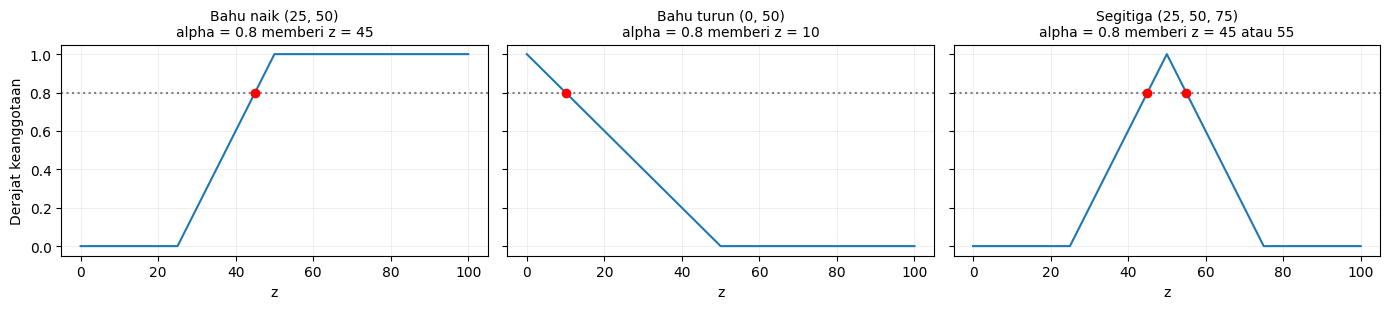

In [3]:
z_grid = np.linspace(0, 100, 1001)
alpha = 0.8
z_up = inverse_linear_up(alpha, 25, 50)
z_down = inverse_linear_down(alpha, 0, 50)
z_left, z_right = 25 + alpha * (50 - 25), 75 - alpha * (75 - 50)  # dua kaki segitiga (25, 50, 75)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.2), sharey=True)
axes[0].plot(z_grid, [linear_up(z, 25, 50) for z in z_grid])
axes[0].scatter([z_up], [alpha], color="red", zorder=3)
axes[0].set_title(f"Bahu naik (25, 50)\nalpha = {alpha} memberi z = {z_up:g}", fontsize=10)
axes[1].plot(z_grid, [linear_down(z, 0, 50) for z in z_grid])
axes[1].scatter([z_down], [alpha], color="red", zorder=3)
axes[1].set_title(f"Bahu turun (0, 50)\nalpha = {alpha} memberi z = {z_down:g}", fontsize=10)
axes[2].plot(z_grid, [triangular(z, 25, 50, 75) for z in z_grid])
axes[2].scatter([z_left, z_right], [alpha, alpha], color="red", zorder=3)
axes[2].set_title(f"Segitiga (25, 50, 75)\nalpha = {alpha} memberi z = {z_left:g} atau {z_right:g}", fontsize=10)
for ax in axes:
    ax.axhline(alpha, color="gray", linestyle=":")
    ax.set_xlabel("z")
    ax.grid(alpha=0.2)
axes[0].set_ylabel("Derajat keanggotaan")
plt.tight_layout()
plt.show()

Garis $\alpha=0{,}8$ memotong bahu naik satu kali (di $z=45$) dan bahu turun satu kali (di $z=10$), tetapi memotong segitiga dua kali (di $z=45$ dan $z=55$). Karena itu kurva output Tsukamoto harus monoton.

---
## 4.3 Langkah 1 dan 2: fuzzifikasi dan kekuatan aturan

### Penjelasan

Dua langkah pertama sama dengan Mamdani dan Sugeno. Variabel input **Jarak** $x\in[0,10]$ m: Dekat `linear_down(x, 2, 4)`, Sedang `trapezoidal(x, 1, 4, 6, 9)`, dan Jauh `linear_up(x, 6, 8)`. Untuk $x=3{,}5$ m derajatnya $[0{,}25;\ 5/6;\ 0]$ (dekat, sedang, jauh).

Aturannya sama dengan Notebook 02, tetapi kurva outputnya harus monoton:

| Aturan | Anteseden | Konsekuen | Kurva output |
|---|---|---|---|
| R1 | IF jarak Dekat | THEN kecepatan Rendah | bahu turun $(0,15)$ |
| R2 | IF jarak Sedang | THEN kecepatan Sedang | bahu naik $(5,15)$ |
| R3 | IF jarak Jauh | THEN kecepatan Tinggi | bahu naik $(15,30)$ |

Satu perbedaan dari Notebook 02: label Sedang di sana berbentuk segitiga $(5,15,25)$. Karena segitiga tidak bisa dibalik, di sini diambil kaki kirinya saja, yaitu bahu naik $(5,15)$. Setiap aturan hanya punya satu kondisi, sehingga $\alpha$ sama dengan derajat labelnya: $\alpha=[0{,}25;\ 5/6;\ 0]$.

### Contoh penerapan

In [4]:
def fuzzify_distance(x):
    """Hitung derajat jarak x pada domain praktikum 0 sampai 10 meter."""
    if not np.isfinite(x) or not 0 <= x <= 10:
        raise ValueError("Jarak harus berada pada domain 0-10 meter.")
    return {
        "dekat": linear_down(x, 2, 4),
        "sedang": trapezoidal(x, 1, 4, 6, 9),
        "jauh": linear_up(x, 6, 8),
    }

# Konsekuen monoton tiap aturan: fungsi keanggotaan, inversnya, dan bagian miring [a, b].
speed_rules = [
    {"aturan": "R1", "input": "dekat", "output": "rendah", "mf": linear_down, "inverse": inverse_linear_down, "a": 0, "b": 15},
    {"aturan": "R2", "input": "sedang", "output": "sedang", "mf": linear_up, "inverse": inverse_linear_up, "a": 5, "b": 15},
    {"aturan": "R3", "input": "jauh", "output": "tinggi", "mf": linear_up, "inverse": inverse_linear_up, "a": 15, "b": 30},
]

x = 3.5                    # input crisp: jarak (m)
mu = fuzzify_distance(x)   # derajat tiap label
alphas = np.array([mu[rule["input"]] for rule in speed_rules])
display(pd.DataFrame({
    "aturan": [rule["aturan"] for rule in speed_rules],
    "anteseden": [f'jarak {rule["input"]}' for rule in speed_rules],
    "alpha": alphas,
}).round(4))

,aturan,anteseden,alpha
0,R1,jarak dekat,0.2500
1,R2,jarak sedang,0.8333
2,R3,jarak jauh,0.0000


R1 dan R2 aktif, sedangkan R3 tidak aktif. Tabel ini baru memuat $\alpha_i$; nilai $z_i$ dicari pada langkah berikutnya.

---
## 4.4 Langkah 3: mencari $z_i$

### Penjelasan

Untuk tiap aturan, pakai rumus invers sesuai arah kurva outputnya:

* R1 (turun, 0-15), $\alpha=0{,}25$: $z_1=15-0{,}25\,(15-0)=11{,}25$
* R2 (naik, 5-15), $\alpha=5/6$: $z_2=5+\tfrac56\,(15-5)\approx13{,}33$
* R3 (naik, 15-30), $\alpha=0$: $z_3=15+0\,(30-15)=15$

$z_i$ adalah kecepatan (m/s), bukan derajat. R3 tidak aktif ($\alpha_3=0$), jadi bobotnya 0 dan $z_3$ tidak memengaruhi hasil.

### Contoh penerapan

,aturan,konsekuen,alpha,z_i (m/s)
0,R1,rendah (0-15 m/s),0.2500,11.2500
1,R2,sedang (5-15 m/s),0.8333,13.3333
2,R3,tinggi (15-30 m/s),0.0000,15.0000


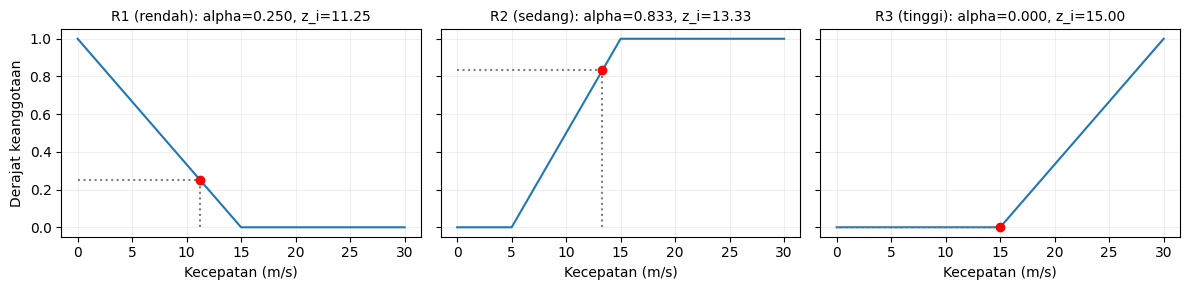

In [5]:
z_values = np.array([
    rule["inverse"](alpha, rule["a"], rule["b"])
    for rule, alpha in zip(speed_rules, alphas)
])
display(pd.DataFrame({
    "aturan": [rule["aturan"] for rule in speed_rules],
    "konsekuen": [f'{rule["output"]} ({rule["a"]}-{rule["b"]} m/s)' for rule in speed_rules],
    "alpha": alphas,
    "z_i (m/s)": z_values,
}).round(4))

speed_grid = np.linspace(0, 30, 301)
fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=True)
for ax, rule, alpha, z_i in zip(axes, speed_rules, alphas, z_values):
    ax.plot(speed_grid, [rule["mf"](s, rule["a"], rule["b"]) for s in speed_grid])
    ax.hlines(alpha, 0, z_i, color="gray", linestyle=":")
    ax.vlines(z_i, 0, alpha, color="gray", linestyle=":")
    ax.scatter([z_i], [alpha], color="red", zorder=3)
    ax.set_title(f'{rule["aturan"]} ({rule["output"]}): alpha={alpha:.3f}, z_i={z_i:.2f}', fontsize=10)
    ax.set_xlabel("Kecepatan (m/s)")
    ax.set_ylim(-0.05, 1.05)
    ax.grid(alpha=0.2)
axes[0].set_ylabel("Derajat keanggotaan")
plt.tight_layout()
plt.show()

Pada kurva turun R1, $\alpha=0{,}25$ memberi $z_1=11{,}25$ m/s. R2 memberi $z_2\approx13{,}33$ m/s. Titik R3 berada di sumbu horizontal karena $\alpha_3=0$.

---
## 4.5 Langkah 4: rata-rata berbobot

### Penjelasan

Gabungkan semua $z_i$ dengan $\alpha_i$ sebagai bobot:

$$z^*=\frac{\sum\alpha_i z_i}{\sum\alpha_i}=\frac{0{,}25\,(11{,}25)+\tfrac56\,(13{,}33)+0\,(15)}{0{,}25+\tfrac56+0}\approx12{,}85\text{ m/s}.$$

Rumus yang sama dipakai pada slide di 4.1: $\alpha=0{,}2$ dengan $z=0{,}5$ dan $\alpha=0{,}5$ dengan $z=5$ memberi $z^*=\dfrac{0{,}2\cdot0{,}5+0{,}5\cdot5}{0{,}2+0{,}5}\approx3{,}71$.

### Contoh penerapan

In [6]:
def weighted_average(weights, values):
    """Hitung rata-rata berbobot dari bobot nonnegatif dan nilai z_i tiap aturan."""
    weights = np.asarray(weights, dtype=float)
    values = np.asarray(values, dtype=float)
    if weights.shape != values.shape or weights.ndim != 1:
        raise ValueError("Bobot dan nilai harus berupa vektor dengan bentuk yang sama.")
    if not np.all(np.isfinite(weights)) or not np.all(np.isfinite(values)):
        raise ValueError("Bobot dan nilai harus bernilai hingga.")
    if np.any(weights < 0):
        raise ValueError("Bobot aturan tidak boleh negatif.")
    total_weight = float(weights.sum())
    if total_weight <= 0:
        raise ValueError("Tidak ada aturan aktif; periksa cakupan anteseden.")
    return float(np.dot(weights, values) / total_weight)

z = weighted_average(alphas, z_values)   # z* pada rumus
display(pd.DataFrame({
    "aturan": [rule["aturan"] for rule in speed_rules],
    "alpha": alphas,
    "z_i (m/s)": z_values,
    "alpha * z_i": alphas * z_values,
    "bobot normal": alphas / alphas.sum(),
}).round(4))
print(f"Jumlah alpha       : {alphas.sum():.4f}")
print(f"Jumlah alpha * z_i : {np.dot(alphas, z_values):.4f}")
print(f"Output Tsukamoto   : {z:.2f} m/s")

# Cek contoh slide halaman 57: alpha_1 = 0,2 dengan z_1 = 0,5; alpha_2 = 0,5 dengan z_2 = 5 (slide menulis mu_y dan y).
print(f"Contoh slide halaman 57: {weighted_average([0.2, 0.5], [0.5, 5]):.2f}")

,aturan,alpha,z_i (m/s),alpha * z_i,bobot normal
0,R1,0.2500,11.2500,2.8125,0.2308
1,R2,0.8333,13.3333,11.1111,0.7692
2,R3,0.0000,15.0000,0.0000,0.0000


Jumlah alpha       : 1.0833
Jumlah alpha * z_i : 13.9236
Output Tsukamoto   : 12.85 m/s
Contoh slide halaman 57: 3.71


Kontribusi R1 sekitar 2,81 dan R2 sekitar 11,11, dibagi total bobot 1,0833, sehingga hasilnya **12,85 m/s**. Baris terakhir mereproduksi 3,71 dari slide.

---
## 4.6 Aplikasi utuh: menguji beberapa jarak

### Penjelasan

Keempat langkah digabung ke fungsi `tsukamoto_speed`, lalu dicoba pada beberapa jarak. Pada 0, 5, dan 10 m hanya satu aturan yang aktif penuh ($\alpha=1$). Coba hitung dulu $z_i$-nya dengan rumus di 4.2, lalu cocokkan dengan hasil kode.

### Contoh penerapan

In [7]:
def tsukamoto_speed(x):
    """Jalankan seluruh tahap Tsukamoto dan kembalikan hasil antaranya."""
    mu = fuzzify_distance(x)
    alphas = np.array([mu[rule["input"]] for rule in speed_rules])
    z_values = np.array([
        rule["inverse"](alpha, rule["a"], rule["b"])
        for rule, alpha in zip(speed_rules, alphas)
    ])
    return {
        "mu": mu,
        "alphas": alphas,
        "z_values": z_values,
        "z": weighted_average(alphas, z_values),
    }

rows = []
for x in [0, 2.5, 3.5, 5, 7.5, 10]:
    result = tsukamoto_speed(x)
    rows.append({"jarak (m)": x, **result["mu"], "kecepatan (m/s)": result["z"]})
display(pd.DataFrame(rows).round(4))

,jarak (m),dekat,sedang,jauh,kecepatan (m/s)
0,0.0,1.00,0.0000,0.00,0.0000
1,2.5,0.75,0.5000,0.00,6.2500
2,3.5,0.25,0.8333,0.00,12.8526
3,5.0,0.00,1.0000,0.00,15.0000
4,7.5,0.00,0.5000,0.75,19.7500
5,10.0,0.00,0.0000,1.00,30.0000


Pada 0, 5, dan 10 m keluarannya tepat **0, 15, dan 30 m/s**: hanya satu aturan aktif sehingga tidak ada yang dirata-ratakan. Pada jarak lain beberapa aturan aktif, dan keluarannya adalah campuran $z_i$ mereka.

---
## 4.7 Perbandingan singkat dengan Mamdani dan Sugeno

### Penjelasan

Ketiga metode memakai aturan dan bobot yang sama. Bedanya hanya cara mengubah hasil tiap aturan menjadi angka:

| | Mamdani | Sugeno | Tsukamoto |
|---|---|---|---|
| Hasil tiap aturan | kurva yang dipotong | angka dari konstanta atau rumus | angka dari kurva monoton (dibalik) |
| Langkah akhir | agregasi, lalu centroid | rata-rata berbobot | rata-rata berbobot |

Slide halaman 62 menunjukkan hal ini pada satu contoh: bobotnya sama ($0{,}3$ dan $0{,}8$), tetapi nilai tiap aturannya berbeda sehingga hasil akhirnya berbeda.

### Contoh penerapan

In [8]:
# Hasil Mamdani dan Sugeno disalin dari Notebook 02 dan 03 (jarak 3,5 m).
display(pd.DataFrame({
    "metode": ["Mamdani max-min + centroid", "Sugeno orde nol", "Sugeno orde satu", "Tsukamoto"],
    "output pada 3,5 m (m/s)": [13.36, 12.69, 11.12, tsukamoto_speed(3.5)["z"]],
}).round(2))

,metode,"output pada 3,5 m (m/s)"
0,Mamdani max-min + centroid,13.36
1,Sugeno orde nol,12.69
2,Sugeno orde satu,11.12
3,Tsukamoto,12.85


Pada 3,5 m keempat model memberi hasil yang berdekatan, yaitu 11 sampai 13,4 m/s. Perbedaannya wajar karena tiap metode mengubah hasil aturan menjadi angka dengan cara berbeda, dan tidak ada yang otomatis paling akurat.

---
## 4.8 Hands-on: perencanaan produksi dengan Tsukamoto

### Penjelasan

Bagian ini adalah praktik terpandu. Kerjakan berurutan: baca instruksi tiap langkah, jalankan sel kodenya, lalu cocokkan angka Anda dengan pembacaan hasil di bawahnya. Berbeda dari contoh jarak pada 4.3 sampai 4.6, sistem ini memiliki **dua input** dan aturan yang memakai **AND**, sehingga seluruh tahap Tsukamoto dilatih sekali lagi dari awal sampai akhir. Soal untuk dikerjakan sendiri ada pada Latihan Soal di bagian paling bawah.

Sebuah pabrik menentukan jumlah produksi harian kemasan barang dari permintaan dan persediaan:

| Variabel | Domain | Label dan fungsi keanggotaan |
|---|---|---|
| Permintaan $x$ | [1000, 5000] kemasan/hari | Turun `linear_down(x, 1000, 5000)`, Naik `linear_up(x, 1000, 5000)` |
| Persediaan $y$ | [100, 600] kemasan | Sedikit `linear_down(y, 100, 600)`, Banyak `linear_up(y, 100, 600)` |
| Produksi $z$ (output) | [2000, 7000] kemasan/hari | Berkurang `linear_down(z, 2000, 7000)`, Bertambah `linear_up(z, 2000, 7000)` |

Kedua label produksi sudah berbentuk bahu sehingga tidak ada yang perlu diganti.

| Aturan | Anteseden | Konsekuen |
|---|---|---|
| R1 | IF permintaan Turun AND persediaan Banyak | THEN produksi Berkurang |
| R2 | IF permintaan Turun AND persediaan Sedikit | THEN produksi Berkurang |
| R3 | IF permintaan Naik AND persediaan Banyak | THEN produksi Bertambah |
| R4 | IF permintaan Naik AND persediaan Sedikit | THEN produksi Bertambah |

Tentukan produksi untuk permintaan **4000** kemasan/hari dan persediaan **300** kemasan.

#### Langkah 1: definisikan himpunan fuzzy

Tulis ketiga variabel sebagai kamus agar setiap label dapat dipanggil lewat namanya, lalu gambarkan agar bentuknya terlihat.

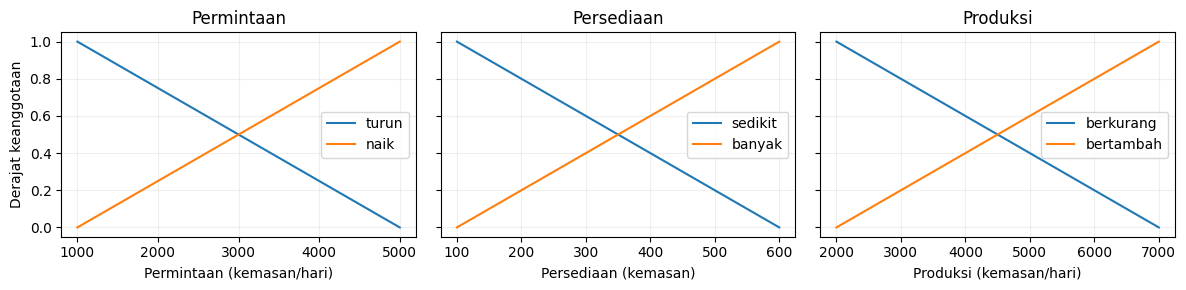

In [9]:
# Himpunan fuzzy input: permintaan (kemasan/hari) dan persediaan (kemasan).
demand_sets = {
    "turun": lambda x: linear_down(x, 1000, 5000),
    "naik": lambda x: linear_up(x, 1000, 5000),
}
stock_sets = {
    "sedikit": lambda y: linear_down(y, 100, 600),
    "banyak": lambda y: linear_up(y, 100, 600),
}
# Konsekuen monoton produksi: fungsi keanggotaan, inversnya, dan bagian miring [a, b].
production_sets = {
    "berkurang": {"mf": linear_down, "inverse": inverse_linear_down, "a": 2000, "b": 7000},
    "bertambah": {"mf": linear_up, "inverse": inverse_linear_up, "a": 2000, "b": 7000},
}

demand_grid = np.linspace(1000, 5000, 401)
stock_grid = np.linspace(100, 600, 501)
production_grid = np.linspace(2000, 7000, 501)
fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=True)
for label, mf in demand_sets.items():
    axes[0].plot(demand_grid, [mf(x) for x in demand_grid], label=label)
for label, mf in stock_sets.items():
    axes[1].plot(stock_grid, [mf(y) for y in stock_grid], label=label)
for label, shoulder in production_sets.items():
    axes[2].plot(production_grid, [shoulder["mf"](z, shoulder["a"], shoulder["b"]) for z in production_grid], label=label)
for ax, title, unit in zip(axes, ["Permintaan", "Persediaan", "Produksi"], ["kemasan/hari", "kemasan", "kemasan/hari"]):
    ax.set_title(title)
    ax.set_xlabel(f"{title} ({unit})")
    ax.legend()
    ax.grid(alpha=0.2)
axes[0].set_ylabel("Derajat keanggotaan")
plt.tight_layout()
plt.show()

Permintaan dan persediaan memakai pasangan bahu turun dan bahu naik yang saling melengkapi: pada setiap titik, jumlah kedua derajatnya 1. Kedua kurva produksi juga bahu, sehingga siap dibalik.

#### Langkah 2: fuzzifikasi

Masukkan permintaan 4000 dan persediaan 300 ke setiap fungsi keanggotaan input.

In [10]:
demand, stock = 4000, 300
demand_degrees = {label: mf(demand) for label, mf in demand_sets.items()}
stock_degrees = {label: mf(stock) for label, mf in stock_sets.items()}
display(pd.concat(
    {f"permintaan = {demand}": pd.Series(demand_degrees), f"persediaan = {stock}": pd.Series(stock_degrees)},
    names=["input", "label"],
).rename("derajat").to_frame())

derajat
input             label           
permintaan = 4000 turun       0.25
                  naik        0.75
persediaan = 300  sedikit     0.60
                  banyak      0.40

Permintaan 4000 adalah Naik sebesar 0,75 dan Turun sebesar 0,25. Persediaan 300 adalah Sedikit sebesar 0,6 dan Banyak sebesar 0,4.

#### Langkah 3: evaluasi aturan

Setiap aturan memakai AND, sehingga $\alpha_i$ adalah minimum dari dua derajat anteseden.

In [11]:
production_rules = [
    {"aturan": "R1", "permintaan": "turun", "persediaan": "banyak", "output": "berkurang"},
    {"aturan": "R2", "permintaan": "turun", "persediaan": "sedikit", "output": "berkurang"},
    {"aturan": "R3", "permintaan": "naik", "persediaan": "banyak", "output": "bertambah"},
    {"aturan": "R4", "permintaan": "naik", "persediaan": "sedikit", "output": "bertambah"},
]
production_alphas = np.array([
    min(demand_degrees[rule["permintaan"]], stock_degrees[rule["persediaan"]])  # AND = min
    for rule in production_rules
])
display(pd.DataFrame({
    "aturan": [rule["aturan"] for rule in production_rules],
    "derajat permintaan": [demand_degrees[rule["permintaan"]] for rule in production_rules],
    "derajat persediaan": [stock_degrees[rule["persediaan"]] for rule in production_rules],
    "alpha = min": production_alphas,
}).round(4))

,aturan,derajat permintaan,derajat persediaan,alpha = min
0,R1,0.25,0.4,0.25
1,R2,0.25,0.6,0.25
2,R3,0.75,0.4,0.40
3,R4,0.75,0.6,0.60


R4 paling kuat ($\alpha=0{,}6$) karena permintaan Naik (0,75) dan persediaan Sedikit (0,6) sama-sama cukup besar. R1 dan R2 dibatasi oleh permintaan Turun yang hanya 0,25.

#### Langkah 4: cari $z_i$ dengan fungsi invers

R1 dan R2 berkonsekuen Berkurang (bahu turun), sedangkan R3 dan R4 berkonsekuen Bertambah (bahu naik). Pilih rumus invers sesuai arah kurvanya.

In [12]:
rows = []
for rule, alpha in zip(production_rules, production_alphas):
    shoulder = production_sets[rule["output"]]
    z = shoulder["inverse"](alpha, shoulder["a"], shoulder["b"])
    rows.append({"aturan": rule["aturan"], "konsekuen": rule["output"], "alpha": alpha, "z_i (kemasan)": z})
production_z = np.array([row["z_i (kemasan)"] for row in rows])
display(pd.DataFrame(rows).round(2))

,aturan,konsekuen,alpha,z_i (kemasan)
0,R1,berkurang,0.25,5750.0
1,R2,berkurang,0.25,5750.0
2,R3,bertambah,0.40,4000.0
3,R4,bertambah,0.60,5000.0


R1 dan R2: $z=7000-0{,}25\,(7000-2000)=5750$. R3: $z=2000+0{,}4\,(7000-2000)=4000$. R4: $z=2000+0{,}6\,(7000-2000)=5000$.

#### Langkah 5: rata-rata berbobot

In [13]:
production = weighted_average(production_alphas, production_z)
print(f"Jumlah alpha       : {production_alphas.sum():.4f}")
print(f"Jumlah alpha * z_i : {np.dot(production_alphas, production_z):.2f}")
print(f"Produksi Tsukamoto : {production:.2f} kemasan/hari")

Jumlah alpha       : 1.5000
Jumlah alpha * z_i : 7475.00
Produksi Tsukamoto : 4983.33 kemasan/hari


Hasilnya $7475/1{,}5\approx4983{,}33$, jadi produksi yang direkomendasikan sekitar **4983 kemasan/hari**.

#### Langkah 6: peta respons

Satu hasil belum cukup untuk melihat perilaku sistem. Bungkus langkah 2 sampai 5 ke satu fungsi, lalu lihat produksi untuk seluruh permintaan pada tiga tingkat persediaan.

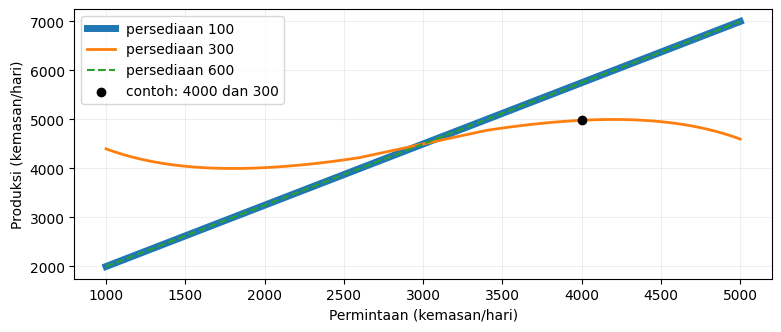

In [14]:
def tsukamoto_production(demand, stock):
    """Jalankan langkah 2 sampai 5 untuk satu pasangan input."""
    d_degrees = {label: mf(demand) for label, mf in demand_sets.items()}
    s_degrees = {label: mf(stock) for label, mf in stock_sets.items()}
    weights, values = [], []
    for rule in production_rules:
        alpha = min(d_degrees[rule["permintaan"]], s_degrees[rule["persediaan"]])
        shoulder = production_sets[rule["output"]]
        weights.append(alpha)
        values.append(shoulder["inverse"](alpha, shoulder["a"], shoulder["b"]))
    return weighted_average(weights, values)

assert np.isclose(tsukamoto_production(4000, 300), production)  # sama dengan hasil langkah 5

sweep_demands = np.linspace(1000, 5000, 81)
plt.figure(figsize=(9, 3.5))
for stock_level, style, width in [(100, "-", 5), (300, "-", 2), (600, "--", 1.5)]:
    plt.plot(sweep_demands, [tsukamoto_production(x, stock_level) for x in sweep_demands], style, linewidth=width, label=f"persediaan {stock_level}")
plt.scatter([4000], [production], color="black", zorder=3, label="contoh: 4000 dan 300")
plt.xlabel("Permintaan (kemasan/hari)")
plt.ylabel("Produksi (kemasan/hari)")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

Garis persediaan 100 dan 600 (ujung domain) berimpit dan berupa garis lurus dari 2000 ke 7000: pada kedua ujung itu hanya permintaan yang menentukan produksi. Pada persediaan 300 (tengah domain), kurvanya bergelombang di sekitar 4000 sampai 5000. Persediaan hanya sebagian Sedikit dan sebagian Banyak, sehingga tidak ada aturan yang mencapai $\alpha=1$ dan keluaran tertarik ke tengah rentang produksi. Ini perilaku sistem, bukan kesalahan hitung: respons Tsukamoto tidak selalu naik terhadap input.

---
## Latihan Soal

Selesaikan tiga kasus berikut dengan **metode Tsukamoto**. Tulis perhitungan manual sebelum memeriksanya dengan Python. Gunakan AND = min, OR = max, dan NOT = $1-\mu$ bila operator tersebut muncul.

Ketiga kasus sama dengan yang ada pada Notebook 02 dan 03 sehingga hasilnya dapat dibandingkan. Fungsi keanggotaan input tidak berubah. Perbedaannya ada pada fungsi output: konsekuen harus monoton, sehingga label yang berbentuk segitiga atau trapesium sudah diganti dengan salah satu kakinya.

Untuk setiap kasus:

1. hitung derajat keanggotaan setiap input dan kekuatan aktivasi $\alpha_i$ seluruh aturan, termasuk yang bernilai nol;
2. tentukan arah (naik atau turun) setiap konsekuen, lalu hitung $z_i$ dengan rumus invers;
3. hitung $\sum\alpha_i$, $\sum\alpha_i z_i$, dan output rata-rata berbobot;
4. periksa bahwa setiap $z_i$ berada pada rentang bagian miring konsekuennya dan output berada di antara $z_i$ aturan aktif; dan
5. jelaskan perubahan output ketika input pembanding diberikan.

Gunakan fungsi dari `membership.py` serta fungsi `inverse_linear_up`, `inverse_linear_down`, dan `weighted_average` yang telah tersedia. Tulis jawaban pada sel kosong; tambahkan sel Markdown atau kode jika diperlukan. Hint tersedia sebagai petunjuk pengerjaan tanpa jawaban akhir.

### Soal 1 - Pengaturan kecepatan kipas

Sebuah pengendali menentukan persentase kecepatan kipas dari suhu ruangan, seperti Soal 1 pada Notebook 02 dan 03. Hitung kecepatan kipas untuk suhu **28°C**, lalu ulangi untuk **36°C**.

**Input suhu** $T\in[10,45]$ °C:

| Label | Fungsi keanggotaan |
|---|---|
| Sejuk | `linear_down(T, 20, 30)` |
| Nyaman | `triangular(T, 20, 30, 40)` |
| Panas | `linear_up(T, 30, 40)` |

**Output kecepatan kipas** $z\in[0,100]$ persen dari kecepatan maksimum. Agar monoton, label Sedang diganti dengan kaki kiri segitiganya:

| Label | Fungsi keanggotaan | Catatan |
|---|---|---|
| Lambat | `linear_down(z, 0, 50)` | sama seperti Notebook 02 |
| Sedang | `linear_up(z, 25, 50)` | pengganti `triangular(z, 25, 50, 75)` |
| Cepat | `linear_up(z, 50, 100)` | sama seperti Notebook 02 |

**Basis aturan:**

| Aturan | Anteseden | Konsekuen |
|---|---|---|
| R1 | IF suhu Sejuk | THEN kecepatan Lambat |
| R2 | IF suhu Nyaman | THEN kecepatan Sedang |
| R3 | IF suhu Panas | THEN kecepatan Cepat |

Kerjakan:

1. Cari semua nilai $z$ yang memberi derajat 0,8 pada `triangular(z, 25, 50, 75)`. Jelaskan mengapa segitiga tidak dapat dipakai sebagai konsekuen Tsukamoto.
2. Hitung kecepatan kipas pada 28°C dan 36°C dengan seluruh tahap Tsukamoto. Sajikan $\alpha_i$ dan $z_i$ setiap aturan dalam tabel.
3. Bandingkan hasilnya dengan Mamdani (Notebook 02, Soal 1) dan Sugeno orde nol (Notebook 03, Soal 1) untuk suhu yang sama, lalu jelaskan sumber perbedaannya.
4. Hitung keluaran Tsukamoto untuk suhu 10-45°C dengan langkah 0,1°C. Apakah keluaran selalu naik ketika suhu naik? Jika tidak, jelaskan penyebabnya dari $\alpha_i$ dan $z_i$.

<details>
<summary>Klik untuk melihat hint</summary>

Untuk bagian 1, tentukan posisi $z$ pada kaki kiri dan kaki kanan segitiga yang memiliki derajat 0,8, lalu tanyakan fungsi invers apa yang dapat ditulis bila ada dua jawaban. Untuk bagian 2, tentukan dulu arah setiap konsekuen (naik atau turun) lalu pilih `inverse_linear_up` atau `inverse_linear_down` yang sesuai; derajat suhu dihitung dari fungsi input, bukan dari fungsi output. Bagian 3 memakai pekerjaan Anda pada Notebook 02 dan 03; bandingkan juga nilai tiap aturan ($z_i$) pada Tsukamoto dengan konsekuen konstan Sugeno. Untuk bagian 4, hitung keluaran pada banyak suhu dalam satu perulangan, lalu periksa selisih antartitik berurutan. Jika ada selisih negatif, bandingkan kontribusi $\alpha_2 z_2$ dan $\alpha_3 z_3$ di sekitar titik tersebut.

</details>

### Soal 2 - Durasi pencucian dengan dua input

Sebuah mesin cuci menentukan durasi pencucian dari indeks kekotoran **65** dan berat pakaian **6,5 kg**, seperti Soal 2 pada Notebook 02 dan 03. Setelah itu, ulangi untuk indeks kekotoran **35** dengan berat tetap 6,5 kg.

**Input kekotoran** $k\in[0,100]$ (indeks tanpa satuan):

| Label | Fungsi keanggotaan |
|---|---|
| Rendah | `linear_down(k, 20, 50)` |
| Sedang | `trapezoidal(k, 20, 40, 60, 80)` |
| Tinggi | `linear_up(k, 50, 80)` |

**Input berat** $b\in[0,10]$ kg:

| Label | Fungsi keanggotaan |
|---|---|
| Ringan | `linear_down(b, 2, 5)` |
| Sedang | `triangular(b, 2, 5, 8)` |
| Berat | `linear_up(b, 5, 8)` |

**Output durasi** $z\in[0,60]$ menit. Agar monoton, label Normal diganti dengan kaki kiri trapesiumnya:

| Label | Fungsi keanggotaan | Catatan |
|---|---|---|
| Singkat | `linear_down(z, 10, 30)` | sama seperti Notebook 02 |
| Normal | `linear_up(z, 15, 25)` | pengganti `trapezoidal(z, 15, 25, 35, 45)` |
| Lama | `linear_up(z, 30, 50)` | sama seperti Notebook 02 |

**Basis aturan:** setiap sel menyatakan konsekuen untuk **kekotoran AND berat pakaian**. Baris menunjukkan kekotoran dan kolom menunjukkan berat, sehingga terdapat sembilan aturan.

| Kekotoran / Berat | Ringan | Sedang | Berat |
|---|---|---|---|
| Rendah | Singkat | Singkat | Normal |
| Sedang | Singkat | Normal | Lama |
| Tinggi | Normal | Lama | Lama |

Beri nama R1-R9 secara berurutan dari kiri ke kanan pada setiap baris, mulai baris Rendah. Kerjakan:

1. Gambarkan ketiga fungsi output, lalu tentukan arah dan bagian miring $[a,b]$ setiap label.
2. Hitung $\alpha_i$ dan $z_i$ untuk R1-R9 pada kondisi awal (kekotoran 65, berat 6,5 kg), lalu hitung durasi pencucian.
3. Ulangi untuk kekotoran 35. Bandingkan kedua durasi dan jelaskan perubahannya melalui aturan yang aktif.
4. Beberapa aturan berbagi label output yang sama, misalnya Lama. Jelaskan bagaimana kontribusi aturan-aturan itu digabung pada Tsukamoto, dan apa bedanya dengan agregasi max pada Mamdani.

<details>
<summary>Klik untuk melihat hint</summary>

Hitung derajat kekotoran dan berat secara terpisah, lalu pasangkan sesuai baris dan kolom tabel aturan dengan AND = min. Setiap sel tabel menunjuk satu label durasi: tentukan arah dan bagian miring label itu sebelum memanggil fungsi invers. Beberapa aturan mengarah ke label yang sama. Untuk menjawab bagian 4, tinjau kembali rumus rata-rata berbobot pada 4.5 untuk melihat bagaimana setiap aturan masuk ke perhitungan, lalu bandingkan dengan cara Mamdani menggabungkan kurva keluaran pada Notebook 02. Aturan dengan $\alpha_i=0$ boleh ikut dihitung karena bobotnya nol. Gunakan fungsi output yang sama saat membandingkan dua kondisi.

</details>

### Soal 3 - Durasi penyiraman dengan AND, OR, dan NOT

Sebuah sistem penyiraman menentukan lama penyiraman dari kelembapan tanah dan suhu udara, seperti Soal 3 pada Notebook 02 dan 03. Sensor menunjukkan **kelembapan tanah 45%** dan **suhu udara 32°C**. Hitung ulang ketika suhu menjadi **27°C**, dengan kelembapan tetap.

**Input kelembapan tanah** $h\in[0,100]$ persen:

| Label | Fungsi keanggotaan |
|---|---|
| Kering | `linear_down(h, 30, 60)` |
| Cukup | `trapezoidal(h, 30, 45, 60, 75)` |
| Basah | `linear_up(h, 60, 80)` |

**Input suhu udara** $T\in[15,40]$ °C:

| Label | Fungsi keanggotaan |
|---|---|
| Sejuk | `linear_down(T, 20, 30)` |
| Panas | `linear_up(T, 25, 35)` |

**Output durasi penyiraman** $z\in[0,30]$ menit. Agar monoton, label Sedang diganti dengan kaki kiri segitiganya:

| Label | Fungsi keanggotaan | Catatan |
|---|---|---|
| Singkat | `linear_down(z, 0, 15)` | sama seperti Notebook 02 |
| Sedang | `linear_up(z, 5, 15)` | pengganti `triangular(z, 5, 15, 25)` |
| Lama | `linear_up(z, 15, 30)` | sama seperti Notebook 02 |

**Basis aturan:**

| Aturan | Anteseden | Konsekuen |
|---|---|---|
| R1 | IF tanah Kering AND suhu Panas | THEN durasi Lama |
| R2 | IF tanah Kering AND NOT (suhu Panas) | THEN durasi Sedang |
| R3 | IF tanah Cukup AND suhu Panas | THEN durasi Sedang |
| R4 | IF tanah Cukup AND NOT (suhu Panas) | THEN durasi Singkat |
| R5 | IF tanah Basah OR suhu Sejuk | THEN durasi Singkat |

Kerjakan:

1. Tuliskan operasi anteseden R1-R5 secara eksplisit untuk 32°C, lalu hitung $\alpha_i$, $z_i$, dan durasi penyiraman.
2. Ulangi untuk suhu 27°C. Bandingkan kekuatan R2, R4, dan R5 pada kedua suhu, lalu jelaskan kontribusinya terhadap perubahan durasi.
3. Pada 32°C, $\alpha_5=0$. Apakah $z_5$ tetap dapat dihitung, dan apakah nilainya memengaruhi hasil? Apa yang terjadi bila seluruh $\alpha_i=0$, dan apakah itu mungkin terjadi pada domain sistem ini?
4. Periksa apakah label Sejuk selalu sama dengan NOT Panas pada seluruh domain suhu.

<details>
<summary>Klik untuk melihat hint</summary>

Hitung `panas` terlebih dahulu, lalu gunakan `1 - panas` hanya pada aturan yang memuat NOT. Hitung `sejuk` secara terpisah untuk R5, yang memakai OR sehingga bobotnya adalah maksimum dari dua derajat. Evaluasi $z_i$ dengan invers sesuai arah konsekuen masing-masing aturan, termasuk R5 walaupun $\alpha_5$ bernilai 0 pada salah satu suhu. Untuk membandingkan dua suhu, tabelkan $\alpha_i$, $z_i$, dan $\alpha_i z_i$ berdampingan, lalu lihat aturan mana yang bobotnya naik dan aturan mana yang $z_i$-nya turun. Untuk pertanyaan tentang seluruh $\alpha_i=0$, tinjau kembali mengapa `weighted_average` menolak jumlah bobot nol, lalu periksa jumlah $\alpha_i$ pada banyak pasangan input. Untuk kesamaan Sejuk dan NOT Panas, bandingkan kedua fungsi pada seluruh domain suhu, bukan pada satu suhu saja.

</details>